<a href="https://colab.research.google.com/github/Terry4715/MVO-backtest/blob/main/codeAlong.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import os
import sys
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive/')

# Define the path to directory
data_path = '/content/drive/MyDrive/ColabNotebooks/EDHEC_Learning'

# Add the directory to sys.path to allow Python to find custom module
if data_path not in sys.path:
    sys.path.append(data_path)

# Import your custom module
import toolkit as tk


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


1935-01    0.0114
1935-02   -0.1274
1935-03   -0.0897
1935-04    0.0796
1935-05   -0.0025
            ...  
2018-08    0.0241
2018-09   -0.0168
2018-10   -0.1002
2018-11   -0.0365
2018-12   -0.1531
Freq: M, Name: SmallCap, Length: 1008, dtype: float64


<Axes: >

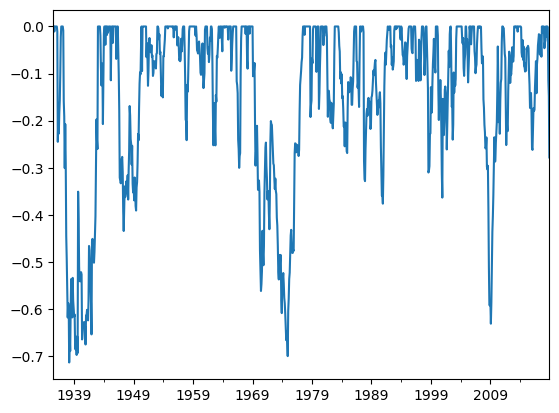

In [2]:
# 5. Use the get_returns function from custom module
returns_data = tk.get_ls_returns()
print(returns_data['1935':]['SmallCap'])

dd = tk.drawdown(returns_data['1935-07':]['SmallCap'])['Drawdown']
dd.plot()



# Deviations from Normality

In [3]:
hfi = tk.get_hf_returns()
hfi["2000":]["CTA Global"].head()

hf_skewness = pd.concat([hfi.mean(), hfi.median(), hfi.mean() > hfi.median()], axis='columns', keys=['Mean', 'Median', 'Negative Skew'])
hf_skewness

,Mean,Median,Negative Skew
Convertible Arbitrage,0.005508,0.0065,False
CTA Global,0.004074,0.0014,True
Distressed Securities,0.006946,0.0089,False
Emerging Markets,0.006253,0.0096,False
Equity Market Neutral,0.004498,0.0051,False
Event Driven,0.006344,0.0084,False
Fixed Income Arbitrage,0.004365,0.0055,False
Global Macro,0.005403,0.0038,True
Long/Short Equity,0.006331,0.0079,False
Merger Arbitrage,0.005356,0.0060,False


# Skewness
$$ S(R) = \frac{E (R-E(R))^3]}{\sigma_R^3} $$

In [4]:
def skewness(r):
  '''
  Alt script to scipy.skew()
  Computes the skewness of the supplied Series or DataFrame
  Returns a float or a Series
  '''

  demeaned_r = r - r.mean()
  # use the population std by setting dof=0
  sigma_r = r.std(ddof=0)
  exp = (demeaned_r**3).mean()
  return exp/sigma_r**3

skewness(hfi)

,0
Convertible Arbitrage,-2.639592
CTA Global,0.173699
Distressed Securities,-1.300842
Emerging Markets,-1.167067
Equity Market Neutral,-2.124435
Event Driven,-1.409154
Fixed Income Arbitrage,-3.940320
Global Macro,0.982922
Long/Short Equity,-0.390227
Merger Arbitrage,-1.320083


In [5]:
import scipy.stats

scipy.stats.skew(hfi)


array([-2.63959223,  0.17369864, -1.30084204, -1.16706749, -2.12443538,
       -1.40915356, -3.94032029,  0.98292188, -0.39022677, -1.32008333,
       -1.81546975,  0.76797484, -0.36178308])

# Kurtosis
$$ K(R) = \frac{E[ (R-E(R))^4 ]}{\sigma_R^4} $$

In [6]:
def kurtosis(r):
  '''
  Alt script to scipy.kurtosis()
  Computes the kurtosis of the supplied Series or DataFrame
  Returns a float or a Series
  '''

  demeaned_r = r - r.mean()
  # use the population std by setting dof=0
  sigma_r = r.std(ddof=0)
  exp = (demeaned_r**4).mean()
  return exp/sigma_r**4

print(kurtosis(hfi))

scipy.stats.kurtosis(hfi)


Convertible Arbitrage     23.280834
CTA Global                 2.952960
Distressed Securities      7.889983
Emerging Markets           9.250788
Equity Market Neutral     17.218555
Event Driven               8.035828
Fixed Income Arbitrage    29.842199
Global Macro               5.741679
Long/Short Equity          4.523893
Merger Arbitrage           8.738950
Relative Value            12.121208
Short Selling              6.117772
Funds Of Funds             7.070153
dtype: float64


array([20.28083446, -0.04703963,  4.88998336,  6.25078841, 14.21855526,
        5.03582817, 26.84219928,  2.74167945,  1.52389258,  5.73894979,
        9.12120787,  3.11777175,  4.07015278])

In [7]:
def is_normal(r, level=0.01):
  '''
  Applies the Jarque-Bera test to determine if a Series is normal or not
  Test is applied at the 1% level by default
  Returns True if the hypothesis of normality is accepted, False otherwise
  '''
  statistic, p_value = scipy.stats.jarque_bera(r)
  return p_value > level

a = hfi.aggregate(is_normal)
print(a)

Convertible Arbitrage     False
CTA Global                 True
Distressed Securities     False
Emerging Markets          False
Equity Market Neutral     False
Event Driven              False
Fixed Income Arbitrage    False
Global Macro              False
Long/Short Equity         False
Merger Arbitrage          False
Relative Value            False
Short Selling             False
Funds Of Funds            False
dtype: bool


# Downside Risk
## Deviations

In [8]:
overall_std = hfi.std(ddof=0)
negative_std = hfi[hfi<0].std(ddof=0)

std_comparison = pd.concat([
    overall_std.rename('Std Dev'),
    negative_std.rename('Neg Std Dev'),
    (negative_std > overall_std).rename('Neg Std Dev > Std Dev')
], axis=1)

std_comparison

,Std Dev,Neg Std Dev,Neg Std Dev > Std Dev
Convertible Arbitrage,0.016536,0.019540,True
CTA Global,0.023290,0.012443,False
Distressed Securities,0.017009,0.015185,False
Emerging Markets,0.032476,0.028039,False
Equity Market Neutral,0.008115,0.009566,True
Event Driven,0.016712,0.015429,False
Fixed Income Arbitrage,0.011517,0.017763,True
Global Macro,0.014694,0.006579,False
Long/Short Equity,0.019897,0.014051,False
Merger Arbitrage,0.009600,0.008875,False


In [9]:
semi_dev = tk.semideviation(hfi)
semi_dev

,0
Convertible Arbitrage,0.019800
CTA Global,0.022163
Distressed Securities,0.020214
Emerging Markets,0.037962
Equity Market Neutral,0.009568
Event Driven,0.019756
Fixed Income Arbitrage,0.015972
Global Macro,0.012588
Long/Short Equity,0.021899
Merger Arbitrage,0.011257


### VaR and CVar
Value At Risk

- Historical VaR (future like past)
- Parametric VaR Guassian (assume dataset just a sample)
- Modified Cornish-Fisher VaR (recognise VaR underestimated with  Guassian distribution)

                        Historical VaR  Guassian VaR  Cornish-Fisher VaR  \
Convertible Arbitrage          0.01576      0.021691            0.025166   
CTA Global                     0.03169      0.034235            0.033094   
Distressed Securities          0.01966      0.021032            0.025102   
Emerging Markets               0.04247      0.047164            0.053011   
Equity Market Neutral          0.00814      0.008850            0.010734   
Event Driven                   0.02535      0.021144            0.025516   
Fixed Income Arbitrage         0.00787      0.014579            0.017881   
Global Macro                   0.01499      0.018766            0.013581   
Long/Short Equity              0.02598      0.026397            0.027935   
Merger Arbitrage               0.01047      0.010435            0.012612   
Relative Value                 0.01174      0.013061            0.016157   
Short Selling                  0.06783      0.080086            0.066157   
Funds Of Fun

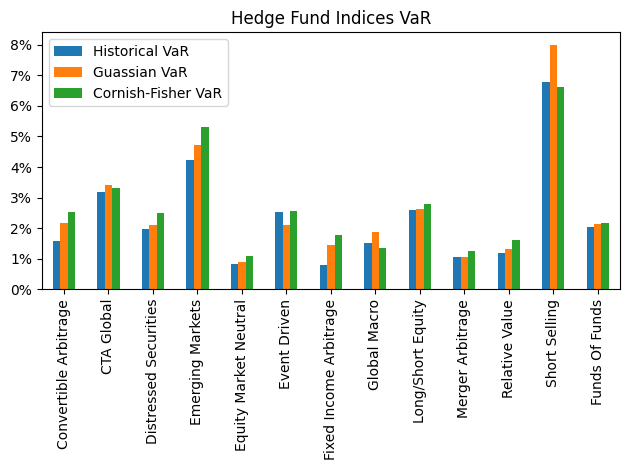

In [10]:
VaR_list = [tk.var_historic(hfi), tk.var_gaussian(hfi), tk.var_gaussian(hfi, modified=True), tk.var_historic(hfi) > tk.var_gaussian(hfi),  tk.var_gaussian(hfi) > tk.var_gaussian(hfi, modified=True)]
comparison = pd.concat(VaR_list, axis='columns', keys=['Historical VaR', 'Guassian VaR', 'Cornish-Fisher VaR', 'Hist > Norm', 'Norm > Fisher'])
print(comparison)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
ax = comparison.plot.bar(title='Hedge Fund Indices VaR')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
plt.tight_layout()
plt.show()

#Beyond VaR aka CVaR (conditional VaR)

In [11]:
# if worst 5% of possible cases happen, the average loss is this output, over the time period
tk.cvar_historic(hfi)

,0
Convertible Arbitrage,0.036550
CTA Global,0.041264
Distressed Securities,0.036429
Emerging Markets,0.072364
Equity Market Neutral,0.016879
Event Driven,0.038336
Fixed Income Arbitrage,0.028257
Global Macro,0.020629
Long/Short Equity,0.041943
Merger Arbitrage,0.019143


In [14]:
# assessment Q1

def get_ls20_returns():
  '''
  Load the montly large and small cap dataset for the top and bottle decile returns by market cap
  '''
  # Define the base path for Google Drive
  gdrive_base_path = '/content/drive/MyDrive/'
  # Construct the full path to the data file
  file_path = os.path.join(gdrive_base_path, 'ColabNotebooks', 'EDHEC_Learning', 'data', 'Portfolios_Formed_on_ME_monthly_EW.csv')

  data = pd.read_csv(file_path, header=0, index_col=0, na_values=-99.99)
  rets = data[['Lo 20','Hi 20']]
  rets.index = pd.to_datetime(rets.index, format='%Y%m').to_period('M')
  rets = rets/100
  return rets

In [23]:
ls20 = get_ls20_returns()
ann_ls20_ret = (1+ls20).prod()**(12/len(ls20)) - 1
print(ann_ls20_ret)
# also Q3 ans

Lo 20    0.151977
Hi 20    0.098490
dtype: float64


In [25]:
# question 2 & 4

monthly_std = ls20.std(ddof=0)
annualized_volatility = monthly_std * np.sqrt(12)
print(annualized_volatility)

Lo 20    0.336550
Hi 20    0.195028
dtype: float64


In [26]:
# question 5 & 7
ls20 = get_ls20_returns()["1999":"2015"]
print(ls20)
ann_ls20_ret = (1+ls20).prod()**(12/len(ls20)) - 1
print(ann_ls20_ret)

          Lo 20   Hi 20
1999-01  0.1114  0.0153
1999-02 -0.0399 -0.0172
1999-03 -0.0308  0.0368
1999-04  0.0824  0.0679
1999-05  0.0435 -0.0048
...         ...     ...
2015-08 -0.0347 -0.0559
2015-09 -0.0610 -0.0333
2015-10  0.0385  0.0710
2015-11  0.0165  0.0015
2015-12 -0.0500 -0.0229

[204 rows x 2 columns]
Lo 20    0.114426
Hi 20    0.062865
dtype: float64


In [27]:
# question 6 & 8
monthly_std = ls20.std(ddof=0)
annualized_volatility = monthly_std * np.sqrt(12)
print(annualized_volatility)

Lo 20    0.228333
Hi 20    0.172289
dtype: float64


In [46]:
# question 9
lo_max_dd = tk.drawdown(ls20['Lo 20'])["Drawdown"].min()
print(lo_max_dd)

-0.6248092431236988


In [47]:
# question 10
lo_max_dd_m = tk.drawdown(ls20['Lo 20'])["Drawdown"].idxmin()
print(lo_max_dd_m)

2009-02


In [50]:
# question 11

hi_max_dd = tk.drawdown(ls20['Hi 20'])['Drawdown'].min()
print(hi_max_dd)

-0.5527349978713653


In [51]:
# question 12

hi_max_dd_m = tk.drawdown(ls20['Hi 20'])['Drawdown'].idxmin()
print(hi_max_dd_m)

2009-02


In [58]:
# question 13

def get_hf_returns():
  '''
  Load the montly hedge fund index returns dataset
  '''
  # Define the base path for Google Drive
  gdrive_base_path = '/content/drive/MyDrive/'
  # Construct the full path to the data file
  file_path = os.path.join(gdrive_base_path, 'ColabNotebooks', 'EDHEC_Learning', 'data', 'edhec-hedgefundindices.csv')

  data = pd.read_csv(file_path, header=0, index_col=0, parse_dates=True, dayfirst=True)
  rets = data/100
  rets.index = rets.index.to_period('M')
  return rets

ahfr = get_hf_returns()
max_std_hf = tk.semideviation(ahfr['2009':'2018']).idxmax()
max_std_hf

'Short Selling'

In [59]:
# question 14
min_std_hf = tk.semideviation(ahfr['2009':'2018']).idxmin()
min_std_hf

'Fixed Income Arbitrage'

In [64]:
# question 15

most_skewed = tk.skewness(ahfr['2009':'2018']).idxmin()
most_skewed

'Equity Market Neutral'

In [66]:
# question 16
high_kurtosis = tk.kurtosis(ahfr['2000':'2018']).idxmax()
high_kurtosis


'Fixed Income Arbitrage'